In [1]:
import pandas as pd
df = pd.read_csv('/content/sales_data.csv')
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [3]:
import sqlite3
conn = sqlite3.connect('/content/sales_data.db')
df.to_sql('sales',conn,if_exists='replace',index=False)

1000

In [4]:
query = """
SELECT
    Product_Category AS product,
    SUM(Quantity_Sold) AS total_quantity,
    SUM(Sales_Amount) AS total_revenue
FROM sales
GROUP BY Product_Category
"""
result_df = pd.read_sql_query(query, conn)


In [5]:
print(result_df)

       product  total_quantity  total_revenue
0     Clothing            6922     1313474.36
1  Electronics            6096     1243499.64
2         Food            5608     1201773.54
3    Furniture            6729     1260517.69


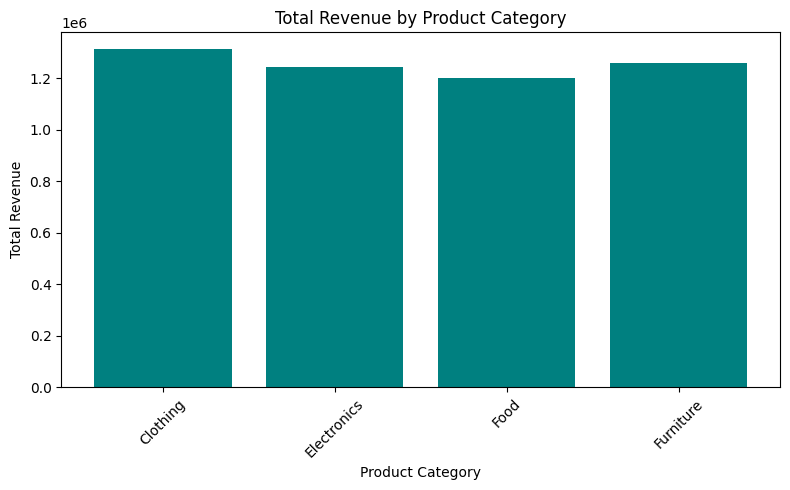

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(result_df['product'], result_df['total_revenue'], color='teal')
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("revenue_by_category.png")
plt.show()
